In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

HARTREE_TO_KCAL_MOL = 627.509474
HARTREE_TO_KJ_MOL = 2625.49962

_RE_FINAL_SP = re.compile(
    r"^\s*FINAL SINGLE POINT ENERGY\s+(-?\d+(?:\.\d+)?)", re.MULTILINE
)
_RE_TOTAL_ENERGY = re.compile(
    r"^\s*Total Energy\s*:\s*(-?\d+(?:\.\d+)?)\s*Eh", re.MULTILINE
)
_RE_FINAL_GIBBS = re.compile(
    r"^\s*Final\s+Gibbs\s+free\s+energy\s*\.\.\.\s*(-?\d+(?:\.\d+)?)\s*Eh",
    re.MULTILINE | re.IGNORECASE,
)


@dataclass(frozen=True)
class EnergyRecord:
    label: str
    path: Path
    energy_hartree: float
    gibbs_hartree: Optional[float] = None


def _read_text(path: Path) -> str:
    return path.read_text(errors="replace")


def extract_final_energy_hartree(log_path: Path) -> float:
    """Extract final energy (Eh) from an ORCA .log.

    Preference order:
    1) last occurrence of 'FINAL SINGLE POINT ENERGY'
    2) last occurrence of 'Total Energy : <...> Eh'
    """
    if not log_path.exists():
        raise FileNotFoundError(str(log_path))

    text = _read_text(log_path)

    m = _RE_FINAL_SP.findall(text)
    if m:
        return float(m[-1])

    m2 = _RE_TOTAL_ENERGY.findall(text)
    if m2:
        return float(m2[-1])

    raise ValueError(f"Energy pattern not found in: {log_path}")


def extract_final_gibbs_hartree(log_path: Path) -> float:
    """Extract final Gibbs free energy (Eh) from an ORCA .log.

    Uses the last occurrence of 'Final Gibbs free energy ... <value> Eh'.
    """
    if not log_path.exists():
        raise FileNotFoundError(str(log_path))

    text = _read_text(log_path)
    m = _RE_FINAL_GIBBS.findall(text)
    if m:
        return float(m[-1])
    raise ValueError(f"Gibbs free energy pattern not found in: {log_path}")


def build_records(log_paths: dict[str, Path]) -> list[EnergyRecord]:
    records: list[EnergyRecord] = []
    for label, path in log_paths.items():
        e = extract_final_energy_hartree(path)
        try:
            g = extract_final_gibbs_hartree(path)
        except Exception:
            g = None
        records.append(
            EnergyRecord(label=label, path=path, energy_hartree=e, gibbs_hartree=g)
        )
    return sorted(records, key=lambda r: ["Backward", "TS", "Forward"].index(r.label))


def find_default_logs(base_dir: Path) -> dict[str, Path]:
    return {
        "Backward": base_dir
        / "Step4_Validate_TS/Step4B_Validate_Forwards_and_Backwards/Backwards/orca.log",
        "TS": base_dir / "Step3_Opt_TS/orca.log",
        "Forward": base_dir
        / "Step4_Validate_TS/Step4B_Validate_Forwards_and_Backwards/Forwards/orca.log",
    }


def find_ccsd_logs(base_dir: Path) -> dict[str, Path]:
    """DLPNO-CCSD(T) (Step5_CCSD) の TS/Backward/Forward ログを返す。"""
    return {
        "Backward": base_dir / "Step5_CCSD/Step5B_Backward/orca.log",
        "TS": base_dir / "Step5_CCSD/Step5A_TS/orca.log",
        "Forward": base_dir / "Step5_CCSD/Step5C_Forward/orca.log",
    }


def to_relative(
    records: list[EnergyRecord],
    ref_label: str = "Backward",
    *,
    g_column: str = "G (Eh)",
    dg_symbol: str = "ΔG",
) -> list[dict]:
    ref = next(r for r in records if r.label == ref_label)
    out: list[dict] = []
    for r in records:
        dEh = r.energy_hartree - ref.energy_hartree
        row: dict = {
            "label": r.label,
            "path": str(r.path),
            "E (Eh)": r.energy_hartree,
            f"ΔE vs {ref_label} (Eh)": dEh,
            f"ΔE vs {ref_label} (kcal/mol)": dEh * HARTREE_TO_KCAL_MOL,
            f"ΔE vs {ref_label} (kJ/mol)": dEh * HARTREE_TO_KJ_MOL,
        }
        if r.gibbs_hartree is not None and ref.gibbs_hartree is not None:
            dGh = r.gibbs_hartree - ref.gibbs_hartree
            row.update(
                {
                    g_column: r.gibbs_hartree,
                    f"{dg_symbol} vs {ref_label} (Eh)": dGh,
                    f"{dg_symbol} vs {ref_label} (kcal/mol)": dGh * HARTREE_TO_KCAL_MOL,
                    f"{dg_symbol} vs {ref_label} (kJ/mol)": dGh * HARTREE_TO_KJ_MOL,
                }
            )
        out.append(row)
    return out


def plot_diagram(
    rel_rows: list[dict],
    ref_label: str = "Backward",
    unit: str = "kcal/mol",
    delta_symbol: str = "ΔE",
    ylabel: str = "Relative energy",
    title: str = "Energy diagram",
    *,
    order: Optional[list[str]] = None,
):
    key = f"{delta_symbol} vs {ref_label} ({unit})"
    order = order or ["Backward", "TS", "Forward"]

    rows_by_label = {r["label"]: r for r in rel_rows}
    missing = [l for l in order if key not in rows_by_label.get(l, {})]
    if missing:
        raise KeyError(f"Missing {key} for: {missing}")
    y = [rows_by_label[l][key] for l in order]

    x = list(range(len(order)))
    plt.figure(figsize=(7, 4))
    plt.plot(x, y, marker="o")
    plt.xticks(x, order)
    plt.ylabel(f"{ylabel} ({unit})")
    plt.title(f"{title} (reference: {ref_label})")

    for xi, yi in zip(x, y):
        plt.annotate(
            f"{yi:.2f}",
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
        )

    plt.tight_layout()
    return plt.gcf()

In [2]:
base_dir = Path.cwd()
print("Notebook working directory:", base_dir)

log_paths = find_default_logs(base_dir)
for k, p in log_paths.items():
    print(f"{k:8s}: {p}  exists={p.exists()}")

records = []
for label, path in log_paths.items():
    e = extract_final_energy_hartree(path)
    try:
        g = extract_final_gibbs_hartree(path)
    except Exception as ex:
        g = None
        print(f"WARN: Gibbs not found for {label}: {ex}")
    records.append(
        EnergyRecord(label=label, path=path, energy_hartree=e, gibbs_hartree=g)
    )

# 並び順を固定
records = sorted(records, key=lambda r: ["Backward", "TS", "Forward"].index(r.label))
rel_rows = to_relative(records, ref_label="Backward")

if pd is not None:
    df = pd.DataFrame(rel_rows)
    display(df)
else:
    for row in rel_rows:
        print(row)

Notebook working directory: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP
Backward: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step4_Validate_TS/Step4B_Validate_Forwards_and_Backwards/Backwards/orca.log  exists=True
TS      : /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step3_Opt_TS/orca.log  exists=True
Forward : /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step4_Validate_TS/Step4B_Validate_Forwards_and_Backwards/Forwards/orca.log  exists=True


,label,path,E (Eh),ΔE vs Backward (Eh),ΔE vs Backward (kcal/mol),ΔE vs Backward (kJ/mol),G (Eh),ΔG vs Backward (Eh),ΔG vs Backward (kcal/mol),ΔG vs Backward (kJ/mol)
0,Backward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.108169,0.000000,0.000000,0.000000,-399.023007,0.000000,0.000000,0.000000
1,TS,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.091102,0.017067,10.709471,44.808425,-399.011940,0.011067,6.944773,29.056929
2,Forward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-399.102162,0.006006,3.769001,15.769499,-399.027188,-0.004181,-2.623611,-10.977188


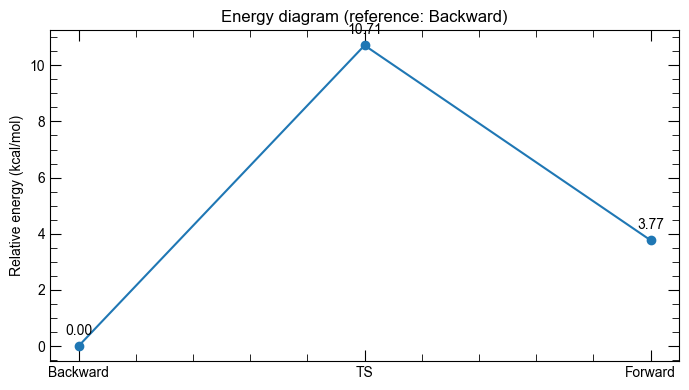

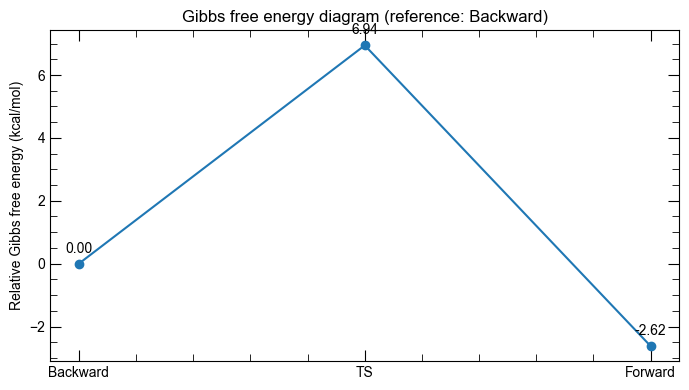

In [3]:
fig_e = plot_diagram(
    rel_rows,
    ref_label="Backward",
    unit="kcal/mol",
    delta_symbol="ΔE",
    ylabel="Relative energy",
    title="Energy diagram",
)
plt.show()

# Gibbs free energy diagram（Gが取れた場合のみ）
try:
    fig_g = plot_diagram(
        rel_rows,
        ref_label="Backward",
        unit="kcal/mol",
        delta_symbol="ΔG",
        ylabel="Relative Gibbs free energy",
        title="Gibbs free energy diagram",
    )
    plt.show()
except Exception as ex:
    print("NOTE: Gibbs diagram was not generated:", ex)

# 画像も保存したい場合は有効化
## out_png = base_dir / 'ts_forward_backward_energy_diagram.png'
## fig_e.savefig(out_png, dpi=200)
## print('Saved:', out_png)

CCSD Backward: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step5_CCSD/Step5B_Backward/orca.log  exists=True
CCSD TS      : /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step5_CCSD/Step5A_TS/orca.log  exists=True
CCSD Forward : /home/yamamoto/Work/chemistry/orca-work/MEA_CO2/conformerA/tpss0/gCP/Step5_CCSD/Step5C_Forward/orca.log  exists=True


,label,path,E (Eh),ΔE vs Backward (Eh),ΔE vs Backward (kcal/mol),ΔE vs Backward (kJ/mol)
0,Backward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.414775,0.000000,0.000000,0.000000
1,TS,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.396141,0.018634,11.693032,48.923646
2,Forward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.407016,0.007759,4.868594,20.370196


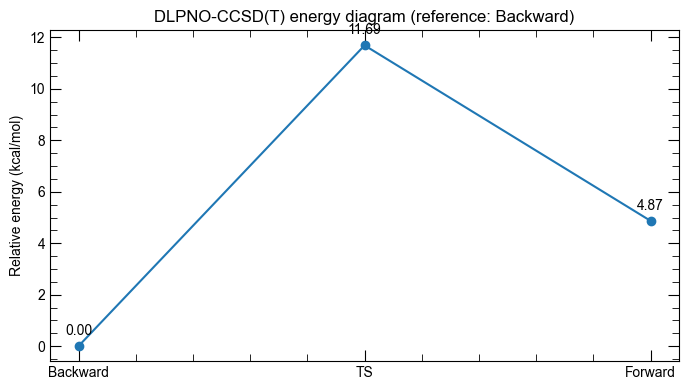

,label,path,E (Eh),ΔE vs Backward (Eh),ΔE vs Backward (kcal/mol),ΔE vs Backward (kJ/mol),G_hybrid (Eh),ΔG_hybrid vs Backward (Eh),ΔG_hybrid vs Backward (kcal/mol),ΔG_hybrid vs Backward (kJ/mol)
0,Backward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.414775,0.000000,0.000000,0.000000,-398.329613,0.000000,0.000000,0.000000
1,TS,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.396141,0.018634,11.693032,48.923646,-398.316978,0.012635,7.928334,33.172150
2,Forward,/home/yamamoto/Work/chemistry/orca-work/MEA_CO...,-398.407016,0.007759,4.868594,20.370196,-398.332042,-0.002429,-1.524018,-6.376491


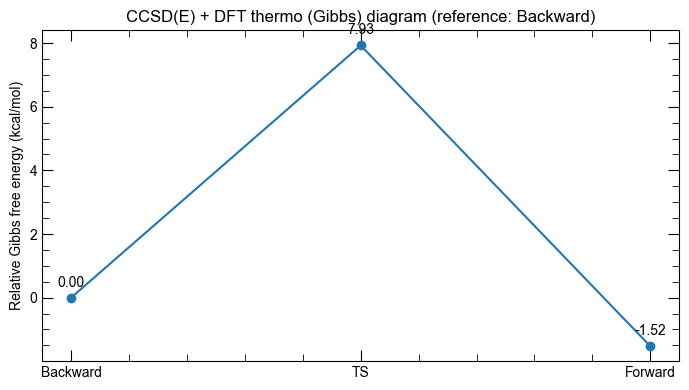

In [4]:
# === Step5_CCSD: DLPNO-CCSD(T) energy diagram ===
ccsd_log_paths = find_ccsd_logs(base_dir)
for k, p in ccsd_log_paths.items():
    print(f"CCSD {k:8s}: {p}  exists={p.exists()}")

# CCSDの電子エネルギー（E）
ccsd_records_e = build_records(ccsd_log_paths)
ccsd_rel_rows_e = to_relative(ccsd_records_e, ref_label="Backward")

if pd is not None:
    df_ccsd_e = pd.DataFrame(ccsd_rel_rows_e)
    display(df_ccsd_e)
else:
    for row in ccsd_rel_rows_e:
        print(row)

fig_ccsd_e = plot_diagram(
    ccsd_rel_rows_e,
    ref_label="Backward",
    unit="kcal/mol",
    delta_symbol="ΔE",
    ylabel="Relative energy",
    title="DLPNO-CCSD(T) energy diagram",
)
plt.show()

# --- Hybrid Gibbs: E(CCSD) + (G-E)(DFT) ---
dft_for_thermo = build_records(find_default_logs(base_dir))
dft_by_label = {r.label: r for r in dft_for_thermo}

thermo_correction = {}  # (G - E) from DFT, in Eh
for lab, dft_r in dft_by_label.items():
    if dft_r.gibbs_hartree is None:
        raise ValueError(
            f"DFT Gibbs free energy missing for {lab}; cannot build hybrid G"
        )
    thermo_correction[lab] = dft_r.gibbs_hartree - dft_r.energy_hartree

ccsd_hybrid_records = []
for r in ccsd_records_e:
    corr = thermo_correction.get(r.label)
    if corr is None:
        raise ValueError(f"Thermal correction missing for {r.label}")
    g_hybrid = r.energy_hartree + corr
    ccsd_hybrid_records.append(
        EnergyRecord(
            label=r.label,
            path=r.path,
            energy_hartree=r.energy_hartree,
            gibbs_hartree=g_hybrid,
        )
    )

ccsd_hybrid_rel_rows = to_relative(
    ccsd_hybrid_records,
    ref_label="Backward",
    g_column="G_hybrid (Eh)",
    dg_symbol="ΔG_hybrid",
)

if pd is not None:
    df_ccsd_hybrid = pd.DataFrame(ccsd_hybrid_rel_rows)
    display(df_ccsd_hybrid)
else:
    for row in ccsd_hybrid_rel_rows:
        print(row)

fig_ccsd_hybrid_g = plot_diagram(
    ccsd_hybrid_rel_rows,
    ref_label="Backward",
    unit="kcal/mol",
    delta_symbol="ΔG_hybrid",
    ylabel="Relative Gibbs free energy",
    title="CCSD(E) + DFT thermo (Gibbs) diagram",
)
plt.show()